<a href="https://colab.research.google.com/github/EL-3raby/Web-Scraping/blob/main/Web_Scraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

print("--- Starting Web Scraping Process ---")

# رابط الموقع (قسم كتب العلوم)
url = "http://books.toscrape.com/catalogue/category/books/science_22/index.html"

# إرسال طلب للموقع لجلب البيانات
response = requests.get(url)


if response.status_code == 200:
    print("✅ Successfully connected to the website!")
    soup = BeautifulSoup(response.content, 'html.parser')
else:
    print("❌ Connection failed.")

--- Starting Web Scraping Process ---
✅ Successfully connected to the website!


In [23]:
# البحث عن كل المنتجات (الكتب) في الصفحة
books = soup.find_all('article', class_='product_pod')

scraped_data = []

# استخراج التفاصيل لكل كتاب
for book in books:
    # 1. اسم الكتاب
    title = book.h3.a['title']

    # 2. السعر (مع تنظيف علامة العملة الغريبة)
    price = book.find('p', class_='price_color').text.replace('Â£', '£')

    # 3. حالة التوفر في المخزن
    availability = book.find('p', class_='instock availability').text.strip()


    rating = book.p['class'][1]

    # إضافة البيانات للقائمة
    scraped_data.append({
        'Product_Name': title,
        'Price': price,
        'Stock_Status': availability,
        'Rating': rating
    })


df_scraped = pd.DataFrame(scraped_data)

print(f"✅ Successfully scraped {len(df_scraped)} products.")
print("\n--- Data Preview ---")
# عرض أول 10 صفوف من البيانات
display(df_scraped.head(10))

✅ Successfully scraped 14 products.

--- Data Preview ---


,Product_Name,Price,Stock_Status,Rating
0,The Most Perfect Thing: Inside (and Outside) a...,£42.96,In stock,Four
1,Immunity: How Elie Metchnikoff Changed the Cou...,£57.36,In stock,Five
2,Sorting the Beef from the Bull: The Science of...,£44.74,In stock,Four
3,Tipping Point for Planet Earth: How Close Are ...,£37.55,In stock,One
4,"The Fabric of the Cosmos: Space, Time, and the...",£55.91,In stock,One
5,Diary of a Citizen Scientist: Chasing Tiger Be...,£28.41,In stock,One
6,The Origin of Species,£10.01,In stock,Four
7,The Grand Design,£13.76,In stock,Three
8,Peak: Secrets from the New Science of Expertise,£16.28,In stock,Two
9,"The Elegant Universe: Superstrings, Hidden Dim...",£13.03,In stock,Four


In [24]:
rating_map = {'One': '1/5', 'Two': '2/5', 'Three': '3/5', 'Four': '4/5', 'Five': '5/5'}
df_scraped['Rating'] = df_scraped['Rating'].map(rating_map)

file_name = 'Scraped_Science_Books.xlsx'
df_scraped.to_excel(file_name, index=False)

print(f"✅ Data cleaned and successfully saved as: {file_name}")
display(df_scraped.head(5))

✅ Data cleaned and successfully saved as: Scraped_Science_Books.xlsx


,Product_Name,Price,Stock_Status,Rating
0,The Most Perfect Thing: Inside (and Outside) a...,£42.96,In stock,4/5
1,Immunity: How Elie Metchnikoff Changed the Cou...,£57.36,In stock,5/5
2,Sorting the Beef from the Bull: The Science of...,£44.74,In stock,4/5
3,Tipping Point for Planet Earth: How Close Are ...,£37.55,In stock,1/5
4,"The Fabric of the Cosmos: Space, Time, and the...",£55.91,In stock,1/5


In [25]:
import datetime

print("--- 🚀 Advanced Data Processing ---")

df_scraped['Price'] = df_scraped['Price'].str.replace('£', '').astype(float)

current_time = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
df_scraped['Scraped_At'] = current_time

print("✅ Prices converted to numbers and Timestamp added.")

df_scraped.to_excel('Books_Data.xlsx', index=False)
df_scraped.to_csv('Books_Data.csv', index=False, encoding='utf-8')
df_scraped.to_json('Books_Data.json', orient='records', indent=4)

print("✅ Data successfully exported to: Excel, CSV, and JSON!")

display(df_scraped.head())

--- 🚀 Advanced Data Processing ---
✅ Prices converted to numbers and Timestamp added.
✅ Data successfully exported to: Excel, CSV, and JSON!


,Product_Name,Price,Stock_Status,Rating,Scraped_At
0,The Most Perfect Thing: Inside (and Outside) a...,42.96,In stock,4/5,2026-04-20 02:58:50
1,Immunity: How Elie Metchnikoff Changed the Cou...,57.36,In stock,5/5,2026-04-20 02:58:50
2,Sorting the Beef from the Bull: The Science of...,44.74,In stock,4/5,2026-04-20 02:58:50
3,Tipping Point for Planet Earth: How Close Are ...,37.55,In stock,1/5,2026-04-20 02:58:50
4,"The Fabric of the Cosmos: Space, Time, and the...",55.91,In stock,1/5,2026-04-20 02:58:50


--- 📊 Chart 1: Price Distribution ---


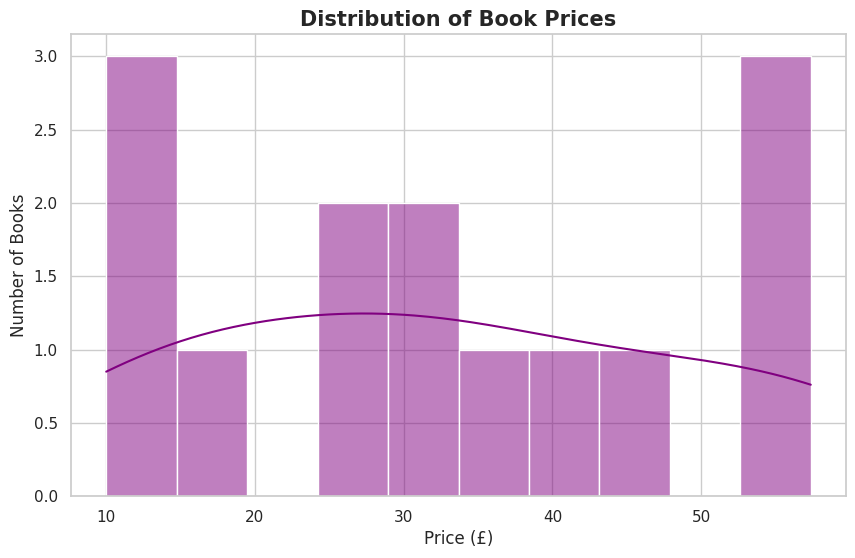

💡 Insight: This shows the most common price range for the scraped books.


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("--- 📊 Chart 1: Price Distribution ---")
plt.figure(figsize=(10, 6))
sns.histplot(df_scraped['Price'], bins=10, kde=True, color='purple')
plt.title('Distribution of Book Prices', fontsize=15, fontweight='bold')
plt.xlabel('Price (£)')
plt.ylabel('Number of Books')
plt.show()

print("💡 Insight: This shows the most common price range for the scraped books.")

--- 📊 Chart 2: Average Price by Rating ---


/tmp/ipykernel_3779/1850369593.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_scraped, x='Rating', y='Price', order=rating_order, palette='Blues')


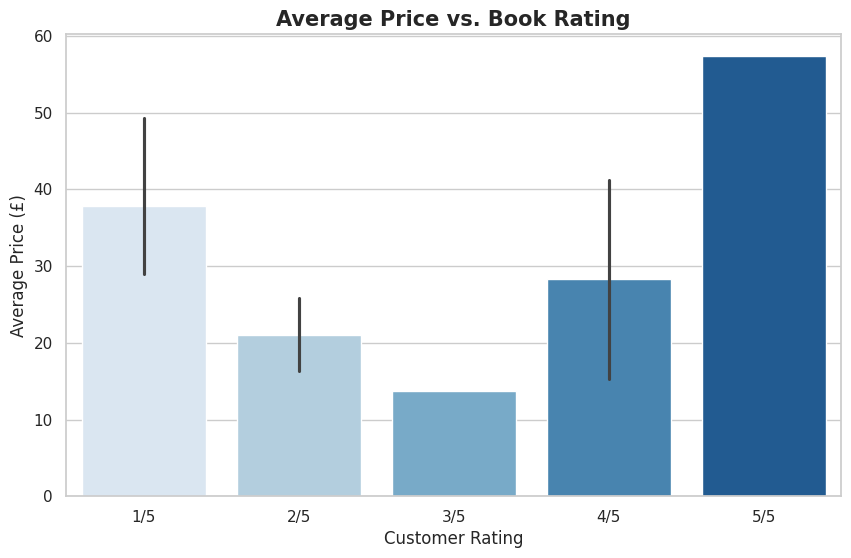

💡 Insight: This chart analyzes if higher-rated books tend to be more expensive.


In [27]:
print("--- 📊 Chart 2: Average Price by Rating ---")
plt.figure(figsize=(10, 6)) # حجم صورة منفصل
rating_order = ['1/5', '2/5', '3/5', '4/5', '5/5']
sns.barplot(data=df_scraped, x='Rating', y='Price', order=rating_order, palette='Blues')
plt.title('Average Price vs. Book Rating', fontsize=15, fontweight='bold')
plt.xlabel('Customer Rating')
plt.ylabel('Average Price (£)')
plt.show()

print("💡 Insight: This chart analyzes if higher-rated books tend to be more expensive.")